In [123]:
import pandas as pd
import matplotlib.pyplot as plt

# EXPLORATION & NETTOYAGE

In [124]:
students = pd.read_csv("student_performance_dataset.csv")
students.sample(4)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
184,185,Male,3.5,92.9,6.8,Masters,Yes,No,No,46.4,85.8,B
247,248,Male,2.9,95.3,7.2,Bachelors,No,No,No,73.9,76.5,C
643,644,Male,2.0,80.1,6.8,Bachelors,No,Yes,No,77.2,70.4,C
649,650,Male,5.9,100.0,7.3,Masters,Yes,Yes,No,61.3,97.3,A


### Renommer certaines colonnes

In [125]:
students = students.rename(columns={
    "attendance_percent": "presence_pct",
    "extracurricular_activities": "activites_extra",
    "study_time_hours": "heures_etude"
})


### Affichage des informations générales

In [126]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          1000 non-null   int64  
 1   gender              1000 non-null   object 
 2   heures_etude        1000 non-null   float64
 3   presence_pct        1000 non-null   float64
 4   sleep_hours         1000 non-null   float64
 5   parental_education  898 non-null    object 
 6   internet_access     1000 non-null   object 
 7   activites_extra     1000 non-null   object 
 8   part_time_job       1000 non-null   object 
 9   previous_grade      1000 non-null   float64
 10  final_exam_score    1000 non-null   float64
 11  final_grade         1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


### Statistiques descriptives

In [127]:
students.describe()

,student_id,heures_etude,presence_pct,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


### Valeurs manquantes

In [128]:
students.isna().sum()

student_id              0
gender                  0
heures_etude            0
presence_pct            0
sleep_hours             0
parental_education    102
internet_access         0
activites_extra         0
part_time_job           0
previous_grade          0
final_exam_score        0
final_grade             0
dtype: int64

### Valeurs dupliquées

In [129]:
students.duplicated().sum()

np.int64(0)

### OBSERVATION SUR LE DESCRIBE

**Au regard du tableau descriptif, toutes les notes sont comprises entre 0 et 100**

**Ici, on va faire simple donc reperer les valeurs négatives et celles superieur a 24h. Suivant cette logique et d'apres le tableau descriptif aucune valeur n'est aberrante**

# STATISTIQUES 

In [130]:
# Calcul de la moyenne de l'examen final
moy_final = students['final_exam_score'].mean()

# Calcul de la mediane de ce meme examen
med_final = students['final_exam_score'].median()

print(f"La moyenne des notes a l'examen final est de {moy_final}")
print(f"La médiane des notes a l'examen final est de {med_final}")

La moyenne des notes a l'examen final est de 83.5435
La médiane des notes a l'examen final est de 83.8


### Calcul de la moyenne par genre

In [131]:
repart_genre = students['gender'].value_counts()
print(f"Repartition des etudiant(e)s par {repart_genre}")

Repartition des etudiant(e)s par gender
Female    510
Male      490
Name: count, dtype: int64


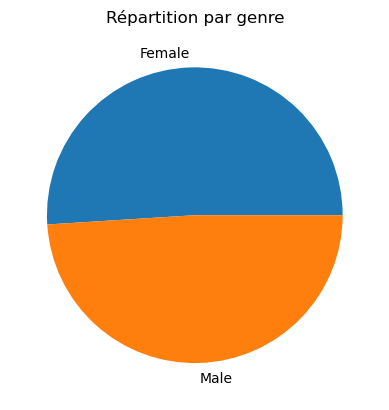

In [132]:
plt.figure()
plt.pie(x = repart_genre.values, labels = repart_genre.index)
plt.title("Répartition par genre")
plt.show()

In [133]:
moy_genre = students.groupby('gender')['final_exam_score'].mean()
moy_genre

gender
Female    83.606863
Male      83.477551
Name: final_exam_score, dtype: float64

**Remarque: La moyenne est sensiblement égale malgré la différence 20 personnes dans le compte entre genre.**

### Repartition des final grade

In [134]:
repartition = students['final_grade'].value_counts()
repartition

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64

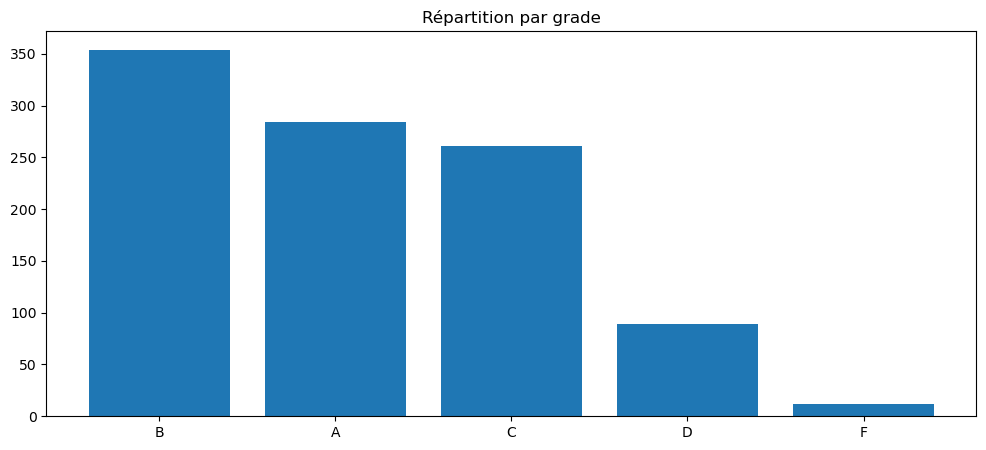

In [135]:
plt.figure(figsize=(12,5))
plt.bar(repartition.index, repartition.values)
plt.title("Répartition par grade")
plt.show()

# ANALYSE CROISEE

### Comparaison de la moyenne des notes finales entre students avec et sans un job a temps partiel

In [142]:
yes_job = students[students['part_time_job'] == 'Yes']
no_job = students[students['part_time_job'] == 'No']

In [143]:
yes_job.sample(3)

,student_id,gender,heures_etude,presence_pct,sleep_hours,parental_education,internet_access,activites_extra,part_time_job,previous_grade,final_exam_score,final_grade
830,831,Male,2.5,80.6,4.8,High School,Yes,No,Yes,60.9,73.5,C
956,957,Female,4.2,89.9,5.6,Masters,Yes,No,Yes,84.7,93.5,A
311,312,Male,1.6,78.2,5.2,Masters,Yes,No,Yes,63.2,63.4,D


In [144]:
no_job.sample(3)

,student_id,gender,heures_etude,presence_pct,sleep_hours,parental_education,internet_access,activites_extra,part_time_job,previous_grade,final_exam_score,final_grade
368,369,Male,2.1,90.1,6.7,High School,No,Yes,No,69.5,67.8,D
305,306,Male,5.2,80.3,6.5,Bachelors,Yes,Yes,No,55.9,80.7,B
217,218,Male,5.5,77.0,5.4,High School,Yes,No,No,76.2,93.4,A


In [145]:
moy_no_job = no_job['final_exam_score'].mean()
moy_yes_job = yes_job['final_exam_score'].mean()

print(f"Students with a job : {moy_yes_job}")
print(f"Students without a job : {moy_no_job}")

Students with a job : 81.29493670886075
Students without a job : 84.58230994152048


**Remarque : Les eleves ayant un job ont une moyenne plus basse que ceux sans job. On peut tirer comme conclusion que le job partiel affecte en genreal les résultats des eleves**

### Détermination de l'impact d'internet

In [146]:
enquete_int = students.pivot_table(values='final_exam_score', index='internet_access', aggfunc='mean')
enquete_int

,final_exam_score
internet_access,
No,79.258219
Yes,84.276112


**Remarque : Fait assez surprenant les éleves ayant acces a internet ont une meilleure moyenne que ceux ne disposant pas d'internet**

### Détermination de l'impact du niveau d'étude des parents

In [149]:
enquete_prt = students.pivot_table(values='final_exam_score', index='parental_education', aggfunc='mean').sort_values(by='parental_education', ascending=False)
enquete_prt

,final_exam_score
parental_education,
PhD,85.062000
Masters,84.034239
High School,83.231461
Bachelors,83.400325


**Remarque : Plus le niveau parental est élevé, plus la moyenne des scores tend à augmenter**

# ALLLONS PLUS LOIN

### Création d'une colonne progression

In [151]:
students['progression'] = students['final_exam_score'] - students['previous_grade']
students.head(3)

,student_id,gender,heures_etude,presence_pct,sleep_hours,parental_education,internet_access,activites_extra,part_time_job,previous_grade,final_exam_score,final_grade,progression
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,23.1
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,24.5
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,8.8


### Détermination de la moyenne de progression

In [152]:
moy_prog = students['progression'].mean()
print(f"En moyenne la note des éleves evolue de {moy_prog} points.")

En moyenne la note des éleves evolue de 13.8026 points.


### Moyenne de présence en cours

In [154]:
moy_pct = students['presence_pct'].mean()
print(f'En moyenne les éleves sont presents a {moy_pct}%')

En moyenne les éleves sont presents a 85.09230000000001%


### Categorisation de l'heure de sommeil 

In [155]:
def sommeil(row) :
    if row['sleep_hours'] < 6 :
        return "Insuffisant"
    elif row['sleep_hours'] <= 8 :
        return "Correct"
    else :
        return "Optimale"

In [157]:
students['cat_sommeil'] = students.apply(sommeil, axis=1)
students['cat_sommeil'].value_counts()

cat_sommeil
Correct        593
Insuffisant    254
Optimale       153
Name: count, dtype: int64

**Remarque : Plus d'un quart des éleves (>250) ont un temps de repos Insuffisant**